<a href="https://colab.research.google.com/github/Listpiquito/TareaExa/blob/main/AnalisisNodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#ANALISIS NODAL



---







In [2317]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


**Datos**



In [2318]:
#Inflow- IPR

In [2319]:
#Pr = 3200       # psi
#Pb = 800        # psi
rw = 0.354      # ft
re = 10000      # ft

Pr_vecino = 4200   # psi (Dato real del pozo vecino LGA-037 en Hollín Inferior)
Pr_frac = 3200     # psi (Dato real del pozo fracturado LGAC-053 en Hollín Superior)
Pb = 800

Pwft_vecino = np.linspace(Pr_vecino, 0, 10)

Pwft_frac = np.linspace(Pr_frac, 0, 10)



In [2320]:
#Indice de Productividad y Factor daño

In [2321]:
J_base = 1.5
S_vecino = 14.5     # Pozo Vecino (Dañado -> EF < 1)
S_frac = -4.5       # Pozo Fracturado (Estimulado -> EF > 1)

In [2322]:
#Datos VLP para formación Hollin

In [2323]:
Pwh = 250       # psi
GLR = 350       # scf/stb
API = 29        # Grados API reales
Eg = 0.72
Eo = 0.88
Dl = 54.9       # lb/ft3
d = 3.5 / 12    # ft (Tubing de 3.5")
e = 0.0006      # ft
Ang = 15
L = 10158       # ft
difL = 508
segmentos = np.full(int(L/difL), difL)

In [2324]:
#funciones

In [2325]:
def modelo_Standing(Pr, J, Pb, Pwft, rw, re, S):
    Q = []
    EF = (np.log(0.472*(re/rw))) / ((np.log(0.472*(re/rw))) + S)
    J1 = J / EF

    if EF < 1:
        if Pr < Pb:
            for pwf in Pwft:
                if pwf > 0:
                    Qt = ((J1*Pr)/1.8)*((1.8*EF*(1-(pwf/Pr))) - (0.8*(EF**2)*((1-(pwf/Pr))**2)))
                    Q.append(round(float(Qt), 3))
                if pwf == 0:
                    Qt = ((J1*Pr)/1.8)*((1.8*EF) - (0.8*(EF**2)))
                    Q.append(round(float(Qt), 3))

        if Pr > Pb:
            for pwf in Pwft:
                if pwf >= Pb:
                    Qt = J * (Pr - pwf)
                    Q.append(round(float(Qt), 3))
                if pwf < Pb and pwf > 0:
                    Qt = (J*(Pr - Pb)) + (((J*Pb)/1.8)*((1.8*(1-(pwf/Pb))) - (0.8*EF*((1-(pwf/Pb))**2))))
                    Q.append(round(float(Qt), 3))
                if pwf == 0:
                    Qt = (J*(Pr - Pb)) + (((J*Pb)/1.8)*(1.8 - (0.8*EF)))
                    Q.append(round(float(Qt), 3))

    if EF > 1:
        if Pr < Pb:
            for pwf in Pwft:
                if pwf > 0:
                    Qt = ((J1*Pr)/1.8)*((1.8*EF*(1-(pwf/Pr))) - (0.8*(EF**2)*((1-(pwf/Pr))**2)))
                    Q.append(round(float(Qt), 3))
                if pwf == 0:
                    Qt = ((J1*Pr)/1.8)*(0.624 + (0.376*EF))
                    Q.append(round(float(Qt), 3))

        if Pr > Pb:
            for pwf in Pwft:
                if pwf >= Pb:
                    Qt = J * (Pr - pwf)
                    Q.append(round(float(Qt), 3))
                if pwf < Pb and pwf > 0:
                    Qt = (J*(Pr - Pb)) + (((J*Pb)/1.8)*((1.8*(1-(pwf/Pb))) - (0.8*EF*((1-(pwf/Pb))**2))))
                    Q.append(round(float(Qt), 3))
                if pwf == 0:
                    Qt = (J*(Pr - Pb)) + (((J1*Pb)/1.8)*(0.624 + 0.376*(EF)))
                    Q.append(round(float(Qt), 3))

    return np.array(Q)

In [2326]:
#funciones para Hagedorn - Brown

In [2327]:
#correlaciones PVT

In [2328]:
def Expancion_gas_Z(P, T, Eg):
    Tpc = 170.5 + 307.3 * Eg; Ppc = 709.6 - 58.7 * Eg
    Ppr = P / Ppc; Tpr = (T + 460) / Tpc
    A = 1.39 * ((Tpr - 0.92)**0.5) - 0.36 * Tpr - 0.101
    B = Ppr * (0.62 - 0.23 * Tpr) + (Ppr**2) * ((0.066 / (Tpr - 0.86)) - 0.037) + ((0.132 * Ppr**6) / 2.72**(20.723 * (Tpr - 1)))
    return A + (1 - A) * 2.72**-B + (0.132 - 0.32 * np.log10(Tpr)) * Ppr**(2.72**(0.715 - 1.128 * Tpr + 0.42 * Tpr**2))


In [2329]:
def Razon_solubilidad_Rs(P, T, API, Eg):
    return Eg * ((P / 18.2 + 1.4) * 10**(0.0125 * API - 0.00091 * T))**1.2048

In [2330]:
def Factor_volumetrico_Bo(Rs, Eg, Eo, T):
    return 0.9759 + 0.000120 * (Rs * (Eg / Eo)**0.5 + 1.25 * T)**1.2

In [2331]:
def Viscosidad_oil_Uo(API, T, Rs):
    Uod = 10**(10**((3.0324 - 0.02023 * API) * (T**-1.163))) - 1
    return (10.715 * (Rs + 100)**-0.515) * Uod**(5.44 * (Rs + 150)**-0.338)

In [2332]:
def Viscosidad_gas_Ug(Eg, T, P, Z):
    M = 28.97 * Eg
    A = ((9.4 + 0.02 * M) * ((T + 460)**1.5)) / (209 + 19 * M + (T + 460))
    B = 3.5 + 0.01 * M + 986 / (T + 460)
    return A * 0.0001 * 2.72**(B * ((0.0433 * Eg * P) / (Z * (T + 460)))**(2.4 - 0.2 * B))

In [2333]:
def Tension_interfacial_TO(API, T, PP):
    return (1 - 0.024 * PP**0.45) * ((39 - 0.2571 * API) - (((T - 68) * 1.5) / 32))

In [2334]:
def Velocidades_Superficial_Mezcla(d, Qo, GLR):
    A = (3.14 * d**2) / 4
    return A, (Qo * 5.6145) / (86400 * A), ((Qo * GLR) / 86400) / A, ((Qo * 5.6145) / (86400 * A)) + (((Qo * GLR) / 86400) / A)

In [2335]:
#calculo del lambdas de liquido y gas

def Lb(Vm, d, Vsl, Vsg):
    Lb_val = 1.071 - 0.2218 * (Vm**2 / d)
    if Lb_val < 0.13: Lb_val = 0.13
    return Vsg / Vm, Vsl / Vm, 'Buble' if (Vsg/Vm) <= Lb_val else 'NoBuble'

In [2336]:
def Numeros_adimensionales(Vsl, Dl, OT, Vsg, d, Uo):
    return 1.938 * Vsl * (Dl / OT)**0.25, 1.938 * Vsg * (Dl / OT)**0.25, 120.872 * d * (Dl / OT)**0.5, 0.15726 * Uo * (1 / (Dl * OT**3))**0.25

In [2337]:
def Holdup_HB(NL, Nvl, Nvg, ND, P):
    CNL = 0.061 * NL**3 - 0.0929 * NL**2 + 0.0505 * NL + 0.0019
    H = (Nvl * (P**0.1) * CNL) / ((Nvg**0.575) * (14.7**0.1) * ND)
    Hl_til = ((0.0047 + 1123.32 * H + 729489.64 * H**2) / (1 + 1097.1566 * H + 722153.97 * H**2))**0.5
    B = (Nvg * NL**0.380) / (ND**2.14)
    til = 2.5714 * B + 1.5962 if B > 0.055 else (-533.33 * B**2 + 58.524 * B + 0.1171 if B > 0.025 else 27170 * B**3 - 317.52 * B**2 + 0.5472 * B + 0.9999)
    return np.round(Hl_til * til, 3)

In [2338]:
#Calculo de las densidades de la mezcla

def calculo_densidades(Dl, Dg, lambl, lambg, Hl):
    return Dl * lambl + Dg * lambg, Dl * Hl + Dg * (1 - Hl), (Dl * lambl + Dg * lambg)**2 / (Dl * Hl + Dg * (1 - Hl))

In [2339]:
#Calculo del factor de friccion

def factor_friccion_bifasico(Uo, Ug, Hl, Dn, Vm, d, e):
    Um = (Uo**Hl) * (Ug**(1-Hl))
    return Um, (148 * Dn * Vm * d) / Um, (1 / (1.14 - 2 * np.log10((e / d) + (21.25 / ((148 * Dn * Vm * d) / Um)**0.9))))**2

In [2340]:
def Gradiente_de_presion(Dm, Ang, f, Df, Vm, d):
    return ((Dm * np.cos((Ang * 3.14) / 180)) / 144) + ((2 * f * Df * Vm**2) / (32.17 * d * 144))

In [2341]:
def Gradiente_Presion_Griffith(Dm, Dl, Qo, f, d, Vm, Vsg):
    return (Dm / 144) + (f * (Dl * Qo)**2) / (74130000000 * 144 * (1 - (1/2)*(1 + (Vm/0.8) - (((1 + (Vm/0.8))**2) - 4*(Vsg/0.8))**0.5)) * d**5)

In [2342]:
def curva_VLP(Qo_arreglo):
    pwfo_resultado = []
    for qo in Qo_arreglo:
        Pcalc = Pwh; T = 90; dT = (188 - 90) / len(segmentos)
        for seg in segmentos:
            Pp = Pcalc; Tp = T
            Z = Expancion_gas_Z(Pp, Tp, Eg); Rs = Razon_solubilidad_Rs(Pp, Tp, API, Eg)
            Bo = Factor_volumetrico_Bo(Rs, Eg, Eo, Tp); Uo = Viscosidad_oil_Uo(API, Tp, Rs)
            Ug = Viscosidad_gas_Ug(Eg, Tp, Pp, Z); OT = Tension_interfacial_TO(API, Tp, Pp)
            Dg = (2.7 * Eg * Pp) / (Z * (Tp + 460))
            A, Vsl, Vsg, Vm = Velocidades_Superficial_Mezcla(d, qo, GLR)
            lambg, lambl, flujo = Lb(Vm, d, Vsl, Vsg)
            Nvl, Nvg, ND, NL = Numeros_adimensionales(Vsl, Dl, OT, Vsg, d, Uo)
            Hl = Holdup_HB(NL, Nvl, Nvg, ND, Pp)
            Dn, Dm, Df = calculo_densidades(Dl, Dg, lambl, lambg, Hl)
            Um, Nrem, f = factor_friccion_bifasico(Uo, Ug, Hl, Dn, Vm, d, e)
            GP = Gradiente_de_presion(Dm, Ang, f, Df, Vm, d) if flujo == 'NoBuble' else Gradiente_Presion_Griffith(Dm, Dl, qo, f, d, Vm, Vsg)
            Pcalc += GP * seg; T += dT
        pwfo_resultado.append(round(Pcalc, 3))
    return np.array(pwfo_resultado)

**Caudales**

In [2343]:
# Pozo Vecino (S=14.5)

#QT_no_frac = modelo_Standing(Pr, J_base, Pb, Pwft_ipr, rw, re, S_vecino)

QT_no_frac = modelo_Standing(Pr_vecino, J_base, Pb, Pwft_vecino, rw, re, S_vecino)

Qmax_no_frac = max(QT_no_frac)
#Qb_no_frac = J_base * (Pr - Pb)
Qb_no_frac = J_base * (Pr_vecino - Pb)
Qb_frac = J_frac_efecto * (Pr_frac - Pb)

# Pozo Fracturado (S=-4.5)
QT_frac = modelo_Standing(Pr_frac, J_base, Pb, Pwft_frac, rw, re, S_frac)

#QT_frac = modelo_Standing(Pr, J_base, Pb, Pwft_ipr, rw, re, S_frac)
Qmax_frac = max(QT_frac)



In [2344]:
# Para el pozo fracturado se calcula el incremento de J inducido por el cambio de EF en el modelo

EF_no_frac = (np.log(0.472*(re/rw))) / ((np.log(0.472*(re/rw))) + S_vecino)

EF_frac = (np.log(0.472*(re/rw))) / ((np.log(0.472*(re/rw))) + S_frac)

J_frac_efecto = J_base * (EF_frac / EF_no_frac)

# Q_b en subsaturado sigue la ley de Darcy lineal

Qb_frac = J_frac_efecto * (Pr - Pb)

In [2345]:
# curvas VLP

Qo_vlp_no_frac = np.linspace(100, Qmax_no_frac, 40)
pwfo_no_frac = curva_VLP(Qo_vlp_no_frac)

Qo_vlp_frac = np.linspace(100, Qmax_frac, 40)
pwfo_frac = curva_VLP(Qo_vlp_frac)

/tmp/ipykernel_34889/2605421026.py:2: RuntimeWarning: invalid value encountered in scalar power
  return 1.938 * Vsl * (Dl / OT)**0.25, 1.938 * Vsg * (Dl / OT)**0.25, 120.872 * d * (Dl / OT)**0.5, 0.15726 * Uo * (1 / (Dl * OT**3))**0.25


In [2346]:
def grafica_Nodal_Personalizada(Pr, Pb, QT, Pwft, Qb, Qo_vlp, pwfo, titulo, color_ipr, color_vlp, lim_x):
    Qmax = max(QT)
    plt.figure(figsize=(10, 8))

    # Curva IPR usando tus estilos
    plt.plot(QT, Pwft, 'o-', color=color_ipr, linewidth=1.5, markersize=4, markerfacecolor='white', label='IPR Standing')

    # Curva VLP integrada
    plt.plot(Qo_vlp, pwfo, 's--', color=color_vlp, linewidth=1.5, markersize=4, markerfacecolor='white', label='VLP Hagedorn & Brown')

    # Líneas de proyección ortogonales en Pb (Yacimiento Subsaturado)
    if Pr > Pb and Pb > 0:
        plt.vlines(x=Qb, ymin=0, ymax=Pb, color='red', linestyle='--', linewidth=1.2)
        plt.hlines(y=Pb, xmin=0, xmax=Qb, color='red', linestyle='--', linewidth=1.2)
        plt.scatter(Qb, Pb, color='red', s=80, zorder=5)
        plt.annotate(f'Pb = {Pb:.0f} psi', (Qb, Pb), xytext=(Qb + (lim_x*0.02), Pb+120), color='red')
        plt.annotate(f'Qb = {Qb:.1f} bpd', (Qb, Pb), xytext=(Qb + (lim_x*0.02), Pb-120), color='black')

    # Pr Anotación
    plt.scatter(0, Pr, color='blue', s=80)
    plt.annotate(f'Pr = {Pr:.0f} psi', (0, Pr), xytext=(lim_x*0.02, Pr-120), color='blue')

    # Qmax Anotación
    plt.scatter(Qmax, 0, color='green', s=80)
    plt.annotate(f'Qmax = {Qmax:.1f} bpd', (Qmax, 0), xytext=(Qmax - (lim_x*0.08), 120), color='green')

    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.ylabel("Presión de fondo fluyente Pwf (psi)")
    plt.xlabel("Tasa de producción Q (bbl/día)")
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.xlim(0, lim_x)
    plt.ylim(0, Pr+200)

    # Configuración de los Ticks de tu código original incluyendo Qb de forma integrada
    paso = int(lim_x / 8)
    rango_normal = np.arange(0, Qmax * 1.05, paso)
    ticks_finales = list(rango_normal)
    if Qb not in ticks_finales: ticks_finales.append(Qb)
    ticks_finales = sorted(ticks_finales)
    etiquetas = [f"{int(x)}" if x != Qb else f"Qb\n({int(x)})" for x in ticks_finales]
    plt.xticks(ticks_finales, labels=etiquetas)

    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [2347]:
#1. Gráfica Pozo Vecino (S = 14.5)

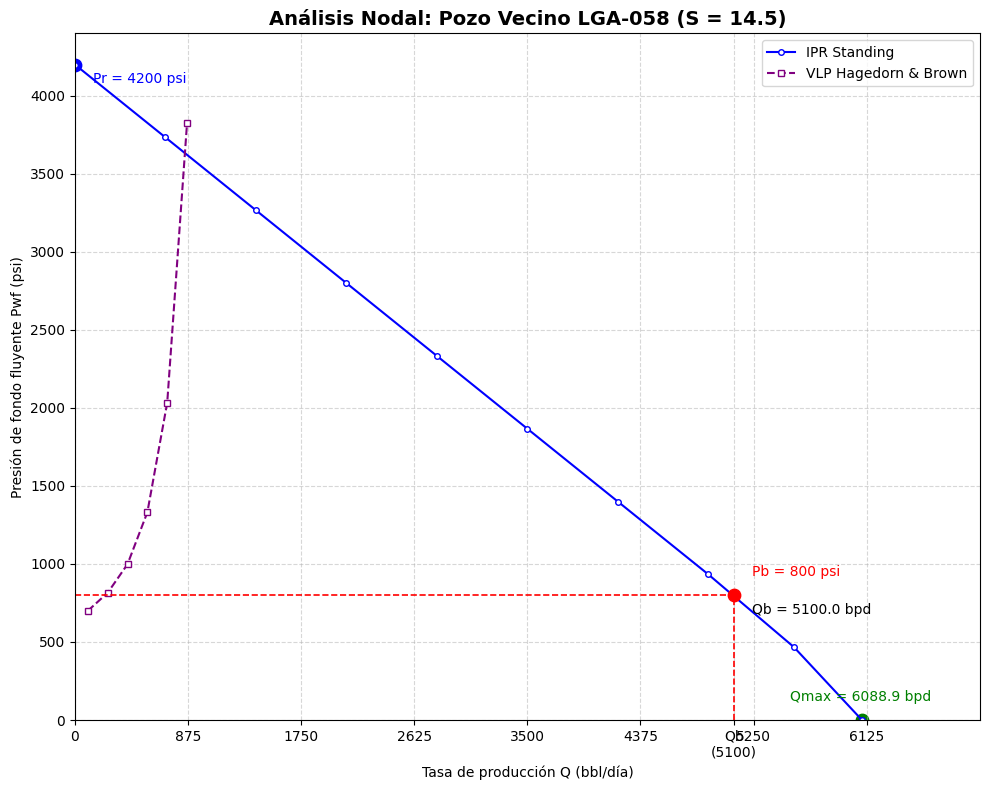

In [2348]:
# Gráfica Individual Pozo Vecino
grafica_Nodal_Personalizada(Pr_vecino, Pb, QT_no_frac, Pwft_vecino, Qb_no_frac, Qo_vlp_no_frac, pwfo_no_frac,
                             "Análisis Nodal: Pozo Vecino LGA-058 (S = 14.5)", "blue", "purple", Qmax_no_frac*1.15)


In [2349]:
# 2. Gráfica Pozo Fracturado (s= -4.5)

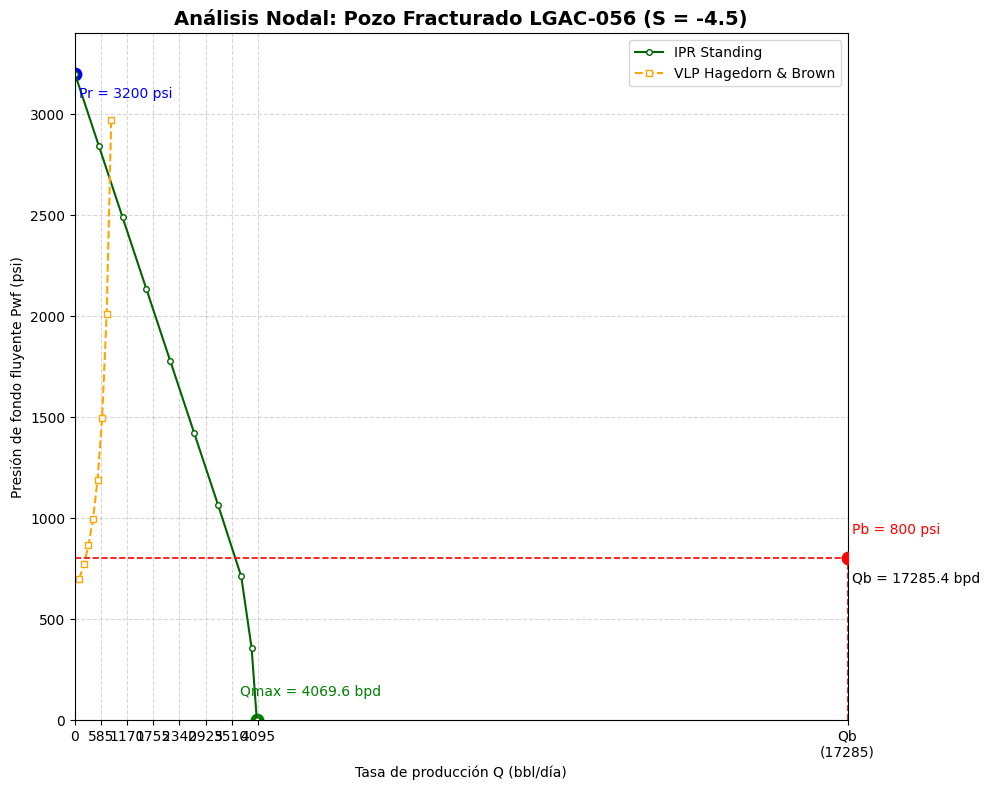

In [2350]:
#grafica_Nodal_Personalizada(Pr2, Pb, QT_frac, Pwft_ipr, Qb_frac, Qo_vlp_frac, pwfo_frac,
#                             "Análisis Nodal: Pozo Fracturado (S = -4.5)", "darkgreen", "orange", Qmax_frac*1.15)

# Gráfica Individual Pozo Fracturado
grafica_Nodal_Personalizada(Pr_frac, Pb, QT_frac, Pwft_frac, Qb_frac, Qo_vlp_frac, pwfo_frac,
                             "Análisis Nodal: Pozo Fracturado LGAC-056 (S = -4.5)", "darkgreen", "orange", Qmax_frac*1.15)

In [2351]:
# Curvas de IPR Standing (Tus resultados calculados con J=1.5 y J=7.2)

def modelo_Standing_IPR(Pr, J, Pb, Pwft):
    Q = []
    for pwf in Pwft:
        if pwf >= Pb: q = J * (Pr - pwf)
        else:
            Qb = J * (Pr - Pb)
            q = Qb + (J * Pb / 1.8) * (1 - 0.2 * (pwf / Pb) - 0.8 * (pwf / Pb)**2)
        Q.append(q)
    return np.array(Q)

QT_no_frac = modelo_Standing_IPR(Pr, 1.5, Pb, Pwft_ipr)
QT_frac = modelo_Standing_IPR(Pr, 7.2, Pb, Pwft_ipr)

In [2352]:
# Función para resolver el bucle VLP segmento por segmento
def resolver_VLP(Qo_arreglo):
    pwfo_resultado = []
    for qo in Qo_arreglo:
        Pcalc = Pwh
        T = 90  # Temp de superficie en °F
        dT = (188 - 90) / len(segmentos)  # Gradiente térmico real hasta llegar a 188 °F

        for seg in segmentos:
            Pp = Pcalc
            Tp = T
            Z = Expancion_gas_Z(Pp, Tp, Eg)
            Rs = Razon_solubilidad_Rs(Pp, Tp, API, Eg)
            Bo = Factor_volumetrico_Bo(Rs, Eg, Eo, Tp)
            Uo = Viscosidad_oil_Uo(API, Tp, Rs)
            Ug = Viscosidad_gas_Ug(Eg, Tp, Pp, Z)
            OT = Tension_interfacial_TO(API, Tp, Pp)
            Dg = (2.7 * Eg * Pp) / (Z * (Tp + 460))

            A, Vsl, Vsg, Vm = Velocidades_Superficial_Mezcla(d, qo, GLR)
            lambg, lambl, flujo = Lb(Vm, d, Vsl, Vsg)
            Nvl, Nvg, ND, NL = Numeros_adimensionales(Vsl, Dl, OT, Vsg, d, Uo)
            Hl = Holdup_HB(NL, Nvl, Nvg, ND, Pp)
            Dn, Dm, Df = calculo_densidades(Dl, Dg, lambl, lambg, Hl)
            Um, Nrem, f = factor_friccion_bifasico(Uo, Ug, Hl, Dn, Vm, d, e)

            if flujo == 'NoBuble':
                GP = Gradiente_de_presion(Dm, Ang, f, Df, Vm, d)
            else:
                GP = Gradiente_Presion_Griffith(Dm, Dl, qo, f, d, Vm, Vsg)

            Pcalc += GP * seg
            T += dT
        pwfo_resultado.append(round(Pcalc, 3))
    return np.array(pwfo_resultado)


In [2353]:
# --- GRÁFICA 1: CASO POZO VECINO (NO FRACTURADO) ---

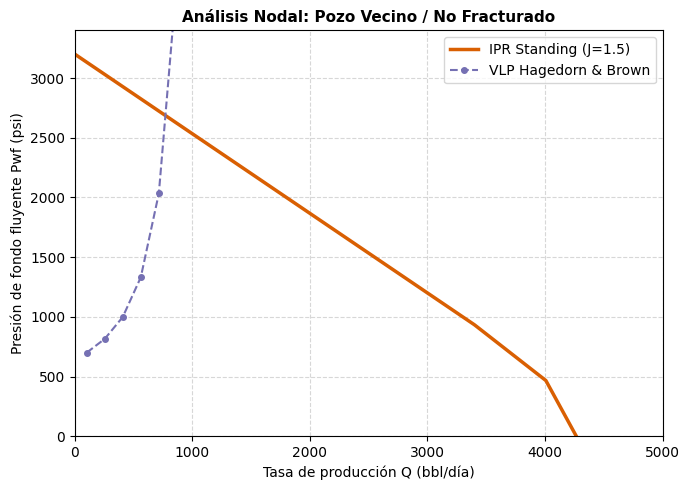

In [2354]:
plt.figure(figsize=(7, 5))
plt.plot(QT_no_frac, Pwft_ipr, color='#d95f02', linewidth=2.5, label='IPR Standing (J=1.5)')
plt.plot(Qo_vlp_no_frac, pwfo_no_frac, color='#7570b3', linestyle='--', marker='o', markersize=4, label='VLP Hagedorn & Brown')
plt.title('Análisis Nodal: Pozo Vecino / No Fracturado', fontsize=11, fontweight='bold')
plt.ylabel("Presión de fondo fluyente Pwf (psi)")
plt.xlabel("Tasa de producción Q (bbl/día)")
plt.xlim(0, 5000)
plt.ylim(0, Pr + 200)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [2355]:
# --- GRÁFICA 2: CASO POZO FRACTURADO ---

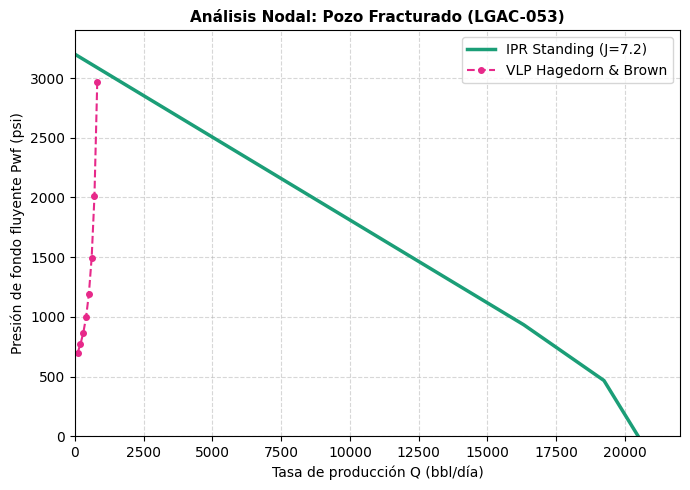

In [2356]:
plt.figure(figsize=(7, 5))
plt.plot(QT_frac, Pwft_ipr, color='#1b9e77', linewidth=2.5, label='IPR Standing (J=7.2)')
plt.plot(Qo_vlp_frac, pwfo_frac, color='#e7298a', linestyle='--', marker='o', markersize=4, label='VLP Hagedorn & Brown')
plt.title('Análisis Nodal: Pozo Fracturado (LGAC-053)', fontsize=11, fontweight='bold')
plt.ylabel("Presión de fondo fluyente Pwf (psi)")
plt.xlabel("Tasa de producción Q (bbl/día)")
plt.xlim(0, 22000)
plt.ylim(0, Pr + 200)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

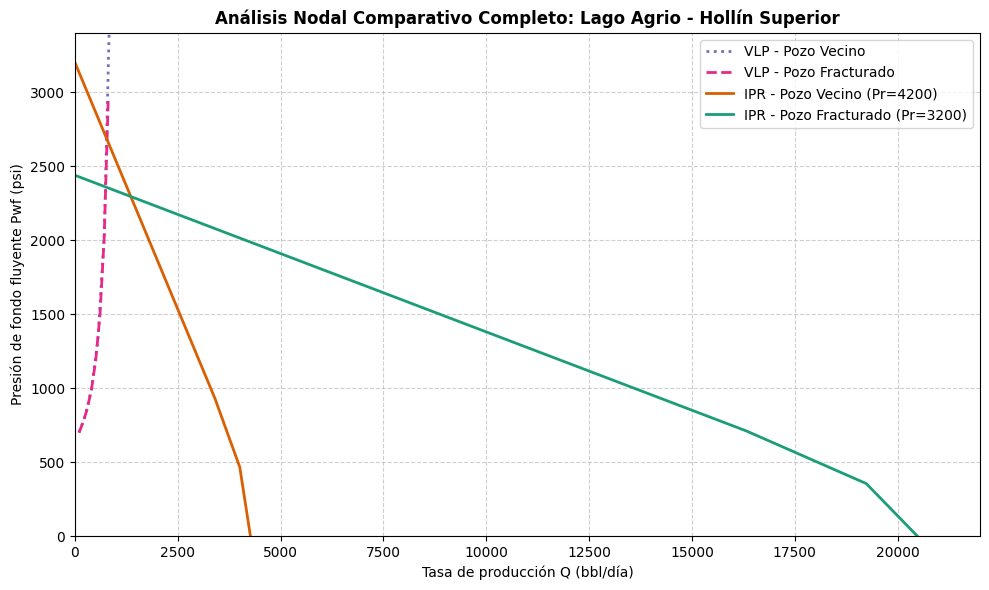

In [2357]:
# --- GRÁFICA 3: UNIÓN FINAL DE AMBOS CASOS ---
plt.figure(figsize=(10, 6))
# Pozo Vecino
#plt.plot(QT_no_frac, Pwft_ipr, color='#d95f02', linewidth=2.5, label='IPR - Pozo Vecino (J=1.5)')
plt.plot(Qo_vlp_no_frac, pwfo_no_frac, color='#7570b3', linestyle=':', linewidth=2, label='VLP - Pozo Vecino')

# Pozo Fracturado
#plt.plot(QT_frac, Pwft_ipr, color='#1b9e77', linewidth=2.5, label='IPR - Pozo Fracturado (J=7.2)')
plt.plot(Qo_vlp_frac, pwfo_frac, color='#e7298a', linestyle='--', linewidth=2, label='VLP - Pozo Fracturado')


# Usamos el vector de presiones correcto para cada curva en el eje Y
plt.plot(QT_no_frac, Pwft_vecino, '-', color='#d95f02', linewidth=2, label='IPR - Pozo Vecino (Pr=4200)')
plt.plot(QT_frac, Pwft_frac, '-', color='#1b9e77', linewidth=2, label='IPR - Pozo Fracturado (Pr=3200)')


# Dibujamos líneas de referencia estáticas para ambos reservorios
#plt.axhline(Pr_vecino, color='#d95f02', linestyle=':', alpha=0.6, label=f'Pr Vecino ({Pr_vecino} psi)')
#plt.axhline(Pr_frac, color='#1b9e77', linestyle=':', alpha=0.6, label=f'Pr Fracturado ({Pr_frac} psi)')

#plt.axhline(Pb, color='blue', linestyle=':', label=f'Pb ({Pb} psi)')
plt.title("Análisis Nodal Comparativo Completo: Lago Agrio - Hollín Superior", fontsize=12, fontweight='bold')
plt.ylabel("Presión de fondo fluyente Pwf (psi)")
plt.xlabel("Tasa de producción Q (bbl/día)")
plt.xlim(0, 22000)
plt.ylim(0, Pr + 200)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [2358]:
######################################################################################################################################################

In [2359]:
#calculos para pozo - curva IPR

In [2360]:
#Dataframe
Tabla_datos = pd.DataFrame({
    'Pwf (psi)': np.round(Pwft, 3),
    'Q (bbl/día)': np.round(QT, 3)})

pd.options.display.float_format = '{:.3f}'.format
print(Tabla_datos)

    Pwf (psi)  Q (bbl/día)
0    3200.000        0.000
1    3089.655      165.517
2    2979.310      331.034
3    2868.966      496.552
4    2758.621      662.069
5    2648.276      827.586
6    2537.931      993.103
7    2427.586     1158.621
8    2317.241     1324.138
9    2206.897     1489.655
10   2096.552     1655.172
11   1986.207     1820.690
12   1875.862     1986.207
13   1765.517     2151.724
14   1655.172     2317.241
15   1544.828     2482.759
16   1434.483     2648.276
17   1324.138     2813.793
18   1213.793     2979.310
19   1103.448     3144.828
20    993.103     3310.345
21    882.759     3475.862
22    772.414     3641.128
23    662.069     3800.622
24    551.724     3952.083
25    441.379     4095.513
26    331.034     4230.911
27    220.690     4358.278
28    110.345     4477.613
29      0.000     4588.915
